In [64]:
##starting new porject notebook for module 5 due to size of previous model projects

In [123]:
## package imports

##computational package
import pandas as pd
import numpy as np

##plotting packages
import seaborn as sns
import matplotlib.pyplot as plt

##ml modules
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from xgboost import XGBClassifier
from xgboost import plot_importance

import pickle

In [66]:
##import data

df=pd.read_csv('tiktok_dataset.csv')

In [67]:
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [68]:
print('Number of row:', df.shape[0])
print('Number of columns', df.shape[1])

Number of row: 19382
Number of columns 12


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [70]:
df.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


In [71]:
df.isna().replace({'False':0, 'True':1}).sum() ## calculates the null values in the dataset. At max there are 298 in a row, these will be dropped

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [72]:
df=df.dropna(axis=0)

In [73]:
df.isna().replace({'False':0, 'True':1}).sum() ##shows that there are now no na values

#                           0
claim_status                0
video_id                    0
video_duration_sec          0
video_transcription_text    0
verified_status             0
author_ban_status           0
video_view_count            0
video_like_count            0
video_share_count           0
video_download_count        0
video_comment_count         0
dtype: int64

In [74]:
df.head(10) ##Check to make sure dataset is still shaped appropriately

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0
6,7,claim,4958886992,16,someone shared with me that elvis presley has ...,not verified,active,750345.0,486192.0,193911.0,8616.0,5446.0
7,8,claim,2270982263,41,someone shared with me that the best selling s...,not verified,active,547532.0,1072.0,50.0,22.0,11.0
8,9,claim,5235769692,50,someone shared with me that about half of the ...,not verified,active,24819.0,10160.0,1050.0,53.0,27.0
9,10,claim,4660861094,45,someone shared with me that it would take a 50...,verified,active,931587.0,171051.0,67739.0,4104.0,2540.0


In [75]:
df.duplicated().replace({'False':0, 'True':1}).sum() ## checks for duplicate rows. Since sum returned to 0, there are no duplicates

np.int64(0)

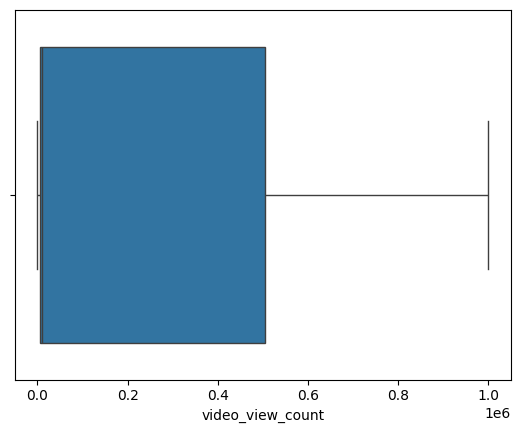

In [76]:
sns.boxplot(
    data = df,
    x='video_view_count',
    flierprops = {'marker': 'o'}
)
plt.show()

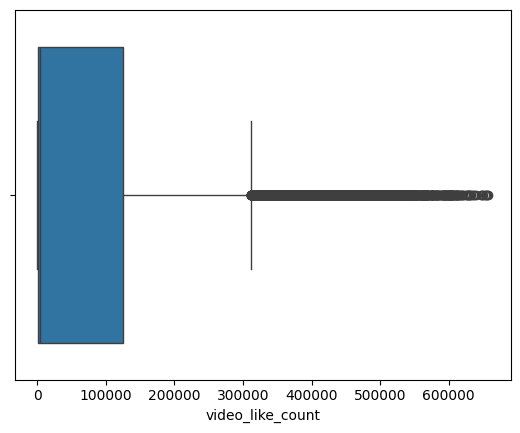

In [77]:
sns.boxplot(
    data = df,
    x='video_like_count',
    flierprops = {'marker': 'o'}
)
plt.show()

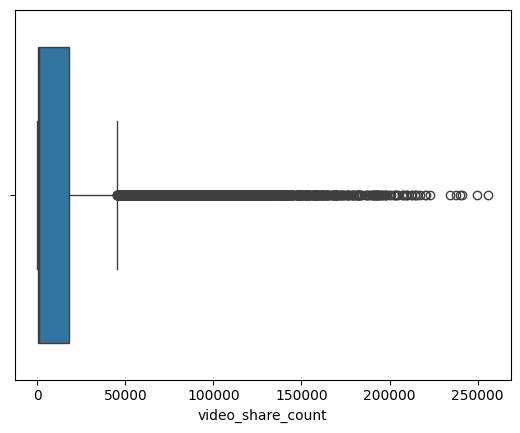

In [78]:
sns.boxplot(
    data = df,
    x='video_share_count',
    flierprops = {'marker': 'o'}
)
plt.show()

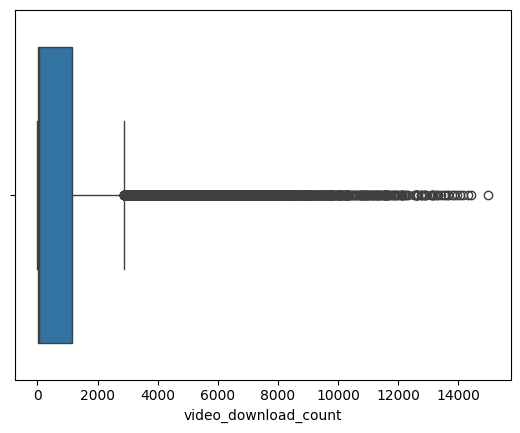

In [79]:
sns.boxplot(
    data = df,
    x='video_download_count',
    flierprops = {'marker': 'o'}
)
plt.show()

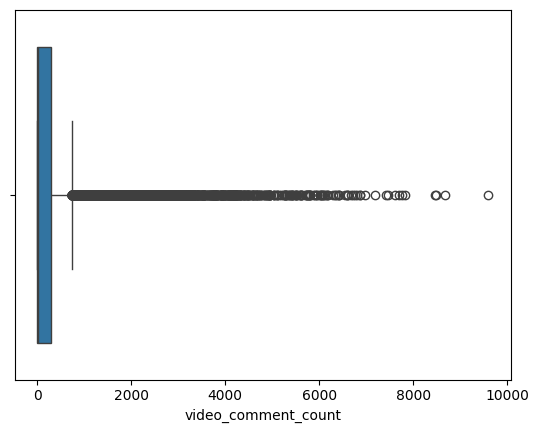

In [80]:
sns.boxplot(
    data = df,
    x='video_comment_count',
    flierprops = {'marker': 'o'}
)
plt.show()

In [81]:
##showing the boxplots of the various video statistics gives an idea of whether there happen to be any outliers. Getting rid of anything considered a 'numerical outlier' in this speicific
##situation may cause skews in the data and there is good reason that these values can happen. For example tik tok videos can go viral, it happens, and when it does, these numbers are
##real. Therefore, i will be keeping all data and assuming that the entered data is correct, as nothing seems to be jumping out that looks blatently stored incorrectly, or something of
##that nature.

In [82]:
df['claim_status'].value_counts(normalize=True)

##Since we are looking to create a predictive model to determine claim status, we check the class balance of the 'claim_status'. Checking shows a near 50/50 split, which should be 
##optimal for this analysis

claim_status
claim      0.503458
opinion    0.496542
Name: proportion, dtype: float64

In [83]:
df['transcription_text_length'] = df['video_transcription_text'].str.len()

In [84]:
df.groupby('claim_status').agg(average_text=('transcription_text_length', 'mean')).reset_index()

,claim_status,average_text
0,claim,95.376978
1,opinion,82.722562


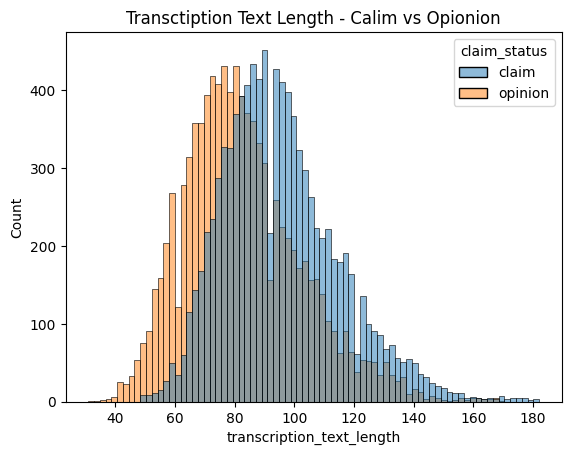

In [85]:
sns.histplot(
    data=df,
    x=df['transcription_text_length'],
    hue=df['claim_status'],
    multiple='layer'
)

plt.title('Transctiption Text Length - Calim vs Opionion')

plt.show()

In [86]:
##Histogram chart shows that transcription text lengths for both claims vs opinions are fairly normally distributed. However, the chart does show that when authors who submit opinions
##tend to average lest text in their complaint than authors that submit claims.

In [87]:
X = df.copy() ## X will act as the columns to use to build the model
X.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,transcription_text_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


In [88]:
X = X.drop(columns=['#', 'video_id', 'video_transcription_text']) ## remove unnessesary columns for model building
X.head()

,claim_status,video_duration_sec,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,transcription_text_length
0,claim,59,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,claim,32,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,claim,31,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,claim,25,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,claim,19,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


In [89]:
X = pd.get_dummies(X, drop_first=True, columns=['verified_status', 'author_ban_status']) ##Get dummy variables for verified status and author ban status 
X.head()

,claim_status,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,transcription_text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,claim,59,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,claim,32,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,claim,31,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,claim,25,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,claim,19,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


In [90]:
X['claim_status'] = X['claim_status'].replace({'opinion': 0, 'claim': 1})
X.head()

##Opinion will be represented by a label 0, and claim will be represented as label 1

C:\Users\matth\AppData\Local\Temp\ipykernel_27824\2345906829.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['claim_status'] = X['claim_status'].replace({'opinion': 0, 'claim': 1})


,claim_status,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,transcription_text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,1,59,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,1,32,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,1,31,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,1,25,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,1,19,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


In [91]:
y = X['claim_status'] ## y will act as the label column 
y.head()

0    1
1    1
2    1
3    1
4    1
Name: claim_status, dtype: int64

In [92]:
X = X.drop(columns=['claim_status'])
X.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,transcription_text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,59,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,32,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,31,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,25,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,19,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


In [93]:
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.25, random_state=42)

In [95]:
print('X train:', X_train.shape[0])
print('X test:', X_test.shape[0])
print('X validate', X_val.shape[0])
print('Sum:', X_train.shape[0]+X_test.shape[0]+X_val.shape[0]) ## Training and testing should sum to 19084, therefore this is a good split.

X train: 11450
X test: 3817
X validate 3817
Sum: 19084


In [96]:
rf = RandomForestClassifier(random_state=0)

In [97]:
cv_params = {'max_depth': [5,7, None], 
             'min_samples_leaf': [1,2],
             'min_samples_split': [2,3],
             'max_samples': [0.7],
             'max_features': [0.3,0.6],
             'n_estimators': [75, 100, 200]
             } 


In [98]:
split_index = [0 if x in X_val.index else -1 for x in X_train.index]
custom_split = PredefinedSplit(split_index)

In [99]:
scoring = ['accuracy', 'precision', 'recall', 'f1']

In [100]:
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='recall')

In [101]:
%%time

# rf_cv.fit(X_train, y_train)

CPU times: total: 0 ns
Wall time: 55.6 μs


In [ ]:
#path = 'path removed when uploaded. Upload you path to run notebook'
# with open(path + 'rf_val_model.pickle', 'wb') as to_write:
#     pickle.dump(rf_cv, to_write)

In [103]:
with open(path + 'rf_val_model.pickle', 'rb') as to_read:
    rf_cv = pickle.load(to_read)

In [104]:
rf_cv.best_score_

np.float64(0.9913766326500252)

In [105]:
rf_cv.best_params_

{'max_depth': 5,
 'max_features': 0.6,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [106]:
results_df = pd.DataFrame(rf_cv.cv_results_)
results_df['mean_test_precision'][rf_cv.best_index_]

np.float64(1.0)

In [107]:
##build gradient boosted model

In [108]:
xgb = XGBClassifier(objective='binary:logistic', random_state=0)

cv_params = {
    'max_depth': [4, 8, 12],
    'min_child_weight': [3, 5],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [300,500],
}

scoring = ['accuracy', 'precision', 'recall', 'f1']

xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='recall')

In [109]:
# xgb_cv.fit(X_train, y_train)

In [110]:
# with open(path + 'xgb_cv_model.pickle', 'wb') as to_write:
#     pickle.dump(xgb_cv, to_write)

In [111]:
with open(path + 'xgb_cv_model.pickle', 'rb') as to_read:
    xgb_cv = pickle.load(to_read)

In [112]:
xgb_cv.best_score_

np.float64(0.9901695873374787)

In [113]:
xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 8,
 'min_child_weight': 3,
 'n_estimators': 500}

In [114]:
results_df_xgb = pd.DataFrame(xgb_cv.cv_results_)
results_df_xgb['mean_test_precision'][xgb_cv.best_index_]

np.float64(0.9987836545751779)

In [115]:
y_pred = rf_cv.best_estimator_.predict(X_val)

In [116]:
y_pred

array([1, 0, 0, ..., 0, 0, 1], shape=(3817,))

In [117]:
y_val

1871     1
16574    0
17741    0
17214    0
17821    0
        ..
15929    0
12177    0
18295    0
17339    0
9186     1
Name: claim_status, Length: 3817, dtype: int64

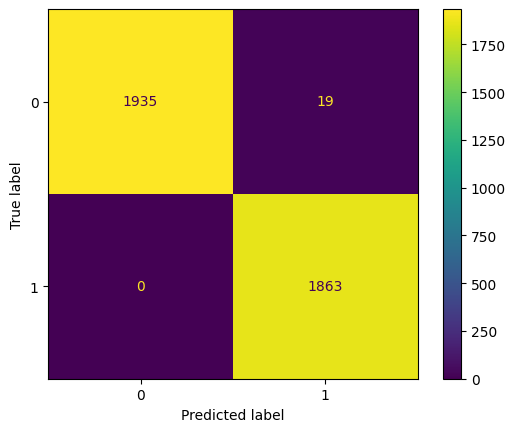

In [122]:
cm = metrics.confusion_matrix(y_pred, y_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_cv.classes_)
disp.plot()

In [125]:
target_labels = ['opionion', 'claim']
print(classification_report(y_val, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

    opionion       0.99      1.00      1.00      1935
       claim       1.00      0.99      0.99      1882

    accuracy                           1.00      3817
   macro avg       1.00      0.99      1.00      3817
weighted avg       1.00      1.00      1.00      3817



In [128]:
y_pred = xgb_cv.best_estimator_.predict(X_val)

In [129]:
y_pred

array([1, 0, 0, ..., 0, 0, 1], shape=(3817,))

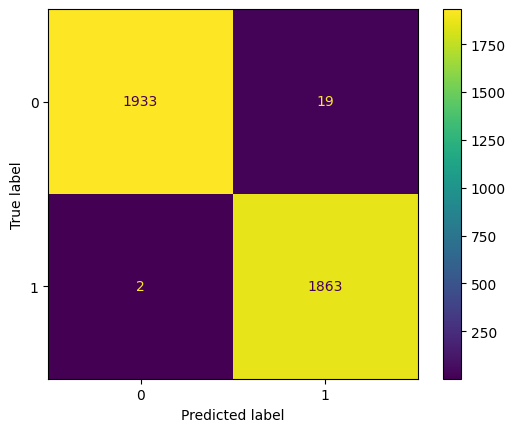

In [130]:
cm = metrics.confusion_matrix(y_pred, y_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_cv.classes_)
disp.plot()

In [131]:
target_labels = ['opionion', 'claim']
print(classification_report(y_val, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

    opionion       0.99      1.00      0.99      1935
       claim       1.00      0.99      0.99      1882

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



In [132]:
## The xgb boosted model performs slightly worse when it comes to predicting false posistives. Therefore, the random forest model is chosen as the 'champion model'. I think it is
## worth noting, that with how both of these models are performing, either could be used a model for this problem.

In [134]:
y_pred = rf_cv.best_estimator_.predict(X_test)

In [135]:
y_pred

array([0, 1, 1, ..., 1, 1, 1], shape=(3817,))

In [138]:
y_test

18920    0
6933     1
351      1
8941     1
385      1
        ..
5925     1
425      1
7391     1
1354     1
8794     1
Name: claim_status, Length: 3817, dtype: int64

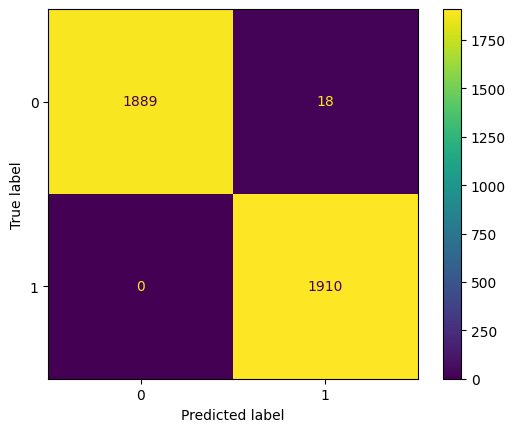

In [139]:
cm = metrics.confusion_matrix(y_pred, y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_cv.classes_)
disp.plot()

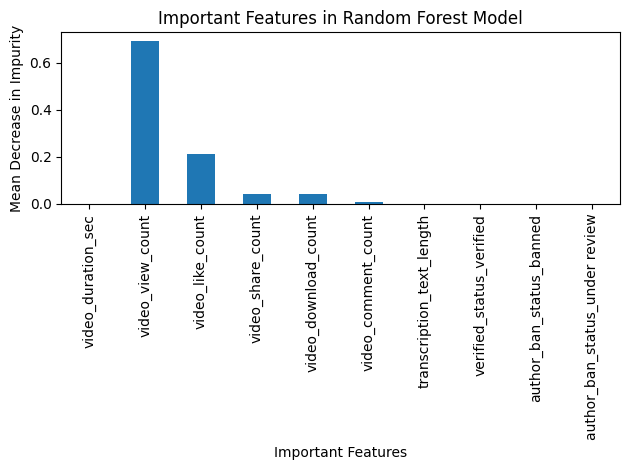

In [146]:
important_features = rf_cv.best_estimator_.feature_importances_
rf_important_features = pd.Series(important_features, index = X_test.columns)

rf_important_features.plot.bar()
plt.xlabel('Important Features')
plt.ylabel('Mean Decrease in Impurity')
plt.title('Important Features in Random Forest Model')
plt.tight_layout()